# 📦 Notebook 01 — Data Loading and Cleaning

**Purpose:** Load all 85 Kickstarter CSV shards, deduplicate, filter to binary outcomes, parse JSON columns, remove leakage and junk columns, audit and fix missing values, and save a single clean parquet file for downstream notebooks.

The train/validation/test split, staff_pick analysis, and post-drop temporal cut are handled in **Notebook 02 (EDA)**.

**Outputs saved to `data/`:**
- `clean_df.parquet` — full cleaned dataset  
- `leakage_columns.json` — reference list of dropped leakage columns

## Data Source

### Origin
Snapshot of Kickstarter campaign data from [WebRobots.io](https://webrobots.io/kickstarter-datasets/), dated **2026-02-12** (token: `Kickstarter_2026-02-12T03_20_22_018Z`).

### Structure
85 CSV shards from paginated API results. The same campaign can appear in multiple shards — deduplication on `id` is mandatory.

| Property | Value |
|---|---|
| Raw rows (after concat) | ~267,673 |
| Unique campaigns (after dedup) | ~209,243 |
| Binary outcome rows | ~188,429 |
| Temporal span | 2009-04-25 → 2026-02-06 |
| Target variable | `success` (1 = funded, 0 = failed) |
| Class balance | ~62% success / ~38% failure |

### Key columns (pre-cleaning)
| Column | Type | Description |
|---|---|---|
| `id` | int | Unique campaign identifier |
| `goal` | float | Funding goal in campaign currency |
| `launched_at` | int (Unix ts) | Campaign launch date |
| `state` | str | successful / failed / live / canceled / ... |
| `pledged` | float | **LEAKAGE** — total raised (post-campaign) |
| `spotlight` | bool | **LEAKAGE** — only awarded to successful campaigns |

### How to reproduce
1. Download the `Kickstarter_2026-02-12T03_20_22_018Z` snapshot from webrobots.io  
2. Unzip into `../data/Kickstarter_2026-02-12T03_20_22_018Z/`  
3. Run this notebook end-to-end

## Setup — Imports and Paths

In [1]:
import os, glob, json, re, warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH    = "../data/Kickstarter_2026-02-12T03_20_22_018Z"
OUTPUTS_PATH = "data"
os.makedirs(OUTPUTS_PATH, exist_ok=True)
FIGURES_PATH = os.path.join(OUTPUTS_PATH, "figures")
os.makedirs(FIGURES_PATH, exist_ok=True)

# Shared colour constants (consistent with Notebook 02)
SUCCESS_COLOR = "#3B82F6"
NEUTRAL_COLOR = "#6B7280"

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.titlesize": 13})

print(f"Data folder : {os.path.abspath(DATA_PATH)}")
print(f"Outputs path: {os.path.abspath(OUTPUTS_PATH)}")

Data folder : /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/data/Kickstarter_2026-02-12T03_20_22_018Z
Outputs path: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/notebooks_final/data


## Step 1 — Load and Merge All 85 CSV Files

All 85 shards share an identical 42-column schema. `low_memory=False` prevents mixed-type inference errors on the JSON string columns (`category`, `location`).

In [2]:
files = sorted(glob.glob(os.path.join(DATA_PATH, "Kickstarter*.csv")))
assert len(files) > 0, f"No CSV files found in {DATA_PATH!r} — check DATA_PATH."
print(f"CSV files found: {len(files)}")

parts = []
for f in files:
    try:
        parts.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  [WARN] {os.path.basename(f)}: {e}")

assert parts, "All CSV files failed to load — check file integrity."
df = pd.concat(parts, ignore_index=True)
del parts  # free memory

print(f"Shape after concat: {df.shape}")

CSV files found: 85
Shape after concat: (267673, 42)


## Step 2 — Deduplicate on `id`

The API paginates results, so the same campaign appears across multiple shards. Keeping one row per `id` is mandatory before any analysis.

In [3]:
n_before = len(df)
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)
print(f"Rows before dedup : {n_before:,}")
print(f"Rows after dedup  : {len(df):,}  ({n_before - len(df):,} duplicates removed)")

Rows before dedup : 267,673
Rows after dedup  : 209,243  (58,430 duplicates removed)


## Step 3 — Filter to Binary Outcome

We keep only `successful` and `failed` campaigns. All other states (`live`, `canceled`, `suspended`, `submitted`, `started`) lack a definitive outcome and cannot be used as ground truth for a binary classifier.

In [4]:
print("State counts before filtering:")
print(df["state"].value_counts())

df = df[df["state"].isin(["successful", "failed"])].reset_index(drop=True)
print(f"\nRows after filtering: {len(df):,}")

State counts before filtering:
state
successful    117627
failed         70802
canceled        9134
submitted       7192
live            2995
started         1488
suspended          5
Name: count, dtype: int64

Rows after filtering: 188,429


## Step 4 — Create the Binary Target Variable

`success = 1` if funded, `success = 0` if failed.

---
### ⚠️ Construct Gap 

**`success` is our observed proxy Y — not the true construct Yc.**

| Symbol | Description | In this project |
|---|---|---|
| **Yc** | True construct — complex, multi-faceted | Campaign quality / creator viability |
| **Y** | Observed proxy — quantifiable but imperfect | Reached funding goal? |

Any metric reported downstream (AUC, F1) measures how well we predict **goal attainment**, not campaign quality. Keep this gap in mind when interpreting results.

In [5]:
df["success"] = (df["state"] == "successful").astype(int)

vc = df["success"].value_counts()
print(f"Funded  : {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)")
print(f"Failed  : {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)")

Funded  : 117,627  (62.4%)
Failed  : 70,802  (37.6%)


## Step 5 — Parse JSON Columns

`category` and `location` store nested metadata as JSON strings. We extract the most useful fields and verify they land in the output:

| Raw column | Extracted fields | Kept in output? |
|---|---|---|
| `category` | `cat_name`, `cat_parent_name` | ✅ Yes |
| `location` | `loc_country`, `loc_state` | ✅ Yes |

The raw JSON columns (`category`, `location`) are dropped in Step 7 once extraction is confirmed.

In [6]:
def safe_json_get(val, key, default=None):
    """Extract a key from a JSON string; falls back to regex on parse failure."""
    try:
        if pd.isna(val):
            return default
        return json.loads(str(val).replace("'", '"')).get(key, default)
    except Exception:
        m = re.search(rf'"{re.escape(key)}"\s*:\s*"([^"]*)"', str(val))
        return m.group(1) if m else default

df["cat_name"]        = df["category"].apply(lambda x: safe_json_get(x, "name"))
df["cat_parent_name"] = df["category"].apply(lambda x: safe_json_get(x, "parent_name"))
df["loc_country"]     = df["location"].apply(lambda x: safe_json_get(x, "country"))
df["loc_state"]       = df["location"].apply(lambda x: safe_json_get(x, "state"))

# Verify all extracted columns are present and non-trivial
for col in ["cat_name", "cat_parent_name", "loc_country", "loc_state"]:
    print(f"{col:<20} unique={df[col].nunique():>4}   missing={df[col].isna().sum():>6,}")

cat_name             unique= 161   missing=     0
cat_parent_name      unique=  15   missing= 4,210
loc_country          unique= 207   missing=   146
loc_state            unique=1196   missing=   195


## Step 6 — Drop Leakage Columns

These columns are available **only after the campaign ends** — including them would mean the model is reading the answer rather than learning to predict it.

| Column | Why it's leakage |
|---|---|
| `pledged`, `usd_pledged`, `converted_pledged_amount` | Total money raised — post-campaign |
| `backers_count` | Number of backers — post-campaign |
| `percent_funded` | `pledged / goal × 100` — the answer as a percentage |
| `spotlight` | **⚠️ Most dangerous**: only awarded to successful campaigns (Pearson r = 1.0 with success) |
| `state_changed_at`, `usd_exchange_rate`, `static_usd_rate`, `fx_rate` | Post-campaign timestamps / settlement rates |

In [7]:
LEAKAGE_COLS = [
    "pledged", "usd_pledged", "converted_pledged_amount",
    "backers_count", "percent_funded", "spotlight",
    "state_changed_at", "usd_exchange_rate", "static_usd_rate", "fx_rate",
]

# Sanity-check: spotlight should be perfectly correlated with success
if "spotlight" in df.columns:
    sp = df["spotlight"].map({"True": 1, "False": 0, True: 1, False: 0}).fillna(0)
    print(f"spotlight ↔ success Pearson r = {sp.corr(df['success']):.4f}  ← must be dropped")

cols_to_drop = [c for c in LEAKAGE_COLS if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} leakage columns.  Shape: {df.shape}")

with open(os.path.join(OUTPUTS_PATH, "leakage_columns.json"), "w") as f:
    json.dump({"leakage_columns": LEAKAGE_COLS}, f, indent=2)

spotlight ↔ success Pearson r = 1.0000  ← must be dropped
Dropped 10 leakage columns.  Shape: (188429, 37)


## Step 7 — Drop Junk / Metadata Columns

The table below justifies every removal. No useful information is lost — extracted fields (`cat_name`, `cat_parent_name`, `loc_country`, `loc_state`, `country`) are all preserved.

| Column(s) | Reason for removal |
|---|---|
| `photo`, `profile`, `urls` | Nested JSON blobs of image/URL metadata — no numeric or categorical signal |
| `creator` | Nested JSON of creator profile — too sparse and unstructured for direct use |
| `source_url`, `slug` | URL-path identifiers — encode no campaign characteristics |
| `currency_symbol`, `currency_trailing_code`, `current_currency` | Fully redundant with the `currency` column |
| `is_liked`, `is_disliked`, `is_starrable` | API interaction flags from the scraping session — not creator attributes |
| `is_in_post_campaign_pledging_phase` | Post-campaign state flag — potential leakage and near-zero variance |
| `usd_type`, `prelaunch_activated` | Sparse platform-internal flags with negligible signal |
| `category`, `location` | Raw JSON — fields already extracted in Step 5; keeping raw form adds no value |
| `is_launched` | **Constant column** — all rows are `True` after the Step 3 filter; zero variance |
| `country_displayable_name` | **Redundant** with the ISO `country` code — same information in verbose form |

In [8]:
JUNK_COLS = [
    "photo", "profile", "urls", "creator", "source_url", "slug",
    "currency_symbol", "currency_trailing_code", "current_currency",
    "is_liked", "is_disliked", "is_starrable",
    "is_in_post_campaign_pledging_phase", "usd_type", "prelaunch_activated",
    "category", "location",
    "is_launched",
    "country_displayable_name",
]

# Defensive: flag any additional constant columns not already listed
extra_constants = [c for c in df.columns if df[c].nunique() == 1 and c not in JUNK_COLS]
if extra_constants:
    print(f"[WARN] Additional constant columns found: {extra_constants}")

df = df.drop(columns=[c for c in JUNK_COLS if c in df.columns])
print(f"Shape after junk drop: {df.shape}")

# Confirm all extracted columns survived
for col in ["cat_name", "cat_parent_name", "loc_country", "loc_state", "country"]:
    status = "✅" if col in df.columns else "❌ MISSING"
    print(f"  {status}  {col}")

Shape after junk drop: (188429, 18)
  ✅  cat_name
  ✅  cat_parent_name
  ✅  loc_country
  ✅  loc_state
  ✅  country


## Step 8 — Drop Audit and Visualisation

This section reconstructs the full cleaning pipeline from the raw CSV files to produce a **transparent audit trail** — showing exactly how many rows and columns were removed at each step and why.

The two charts provide a visual summary that can be referenced in the project presentation.

In [9]:
# ── Rebuild the audit from raw files (requires DATA_PATH to be accessible) ──
raw_files = sorted(glob.glob(os.path.join(DATA_PATH, "Kickstarter*.csv")))

if raw_files:
    _parts = [pd.read_csv(fp, low_memory=False) for fp in raw_files]
    _raw   = pd.concat(_parts, ignore_index=True)
    del _parts

    n0_rows, n0_cols = _raw.shape

    _dedup  = _raw.drop_duplicates(subset=["id"])
    _binary = _dedup[_dedup["state"].isin(["successful", "failed"])]
    _noleak = _binary.drop(columns=[c for c in LEAKAGE_COLS if c in _binary.columns])
    _clean  = _noleak.drop(columns=[c for c in JUNK_COLS   if c in _noleak.columns])

    audit = pd.DataFrame([
        {"step": "Raw concatenated",    "rows": n0_rows,        "cols": n0_cols,          "reason": "Starting point"},
        {"step": "After deduplication", "rows": len(_dedup),    "cols": _dedup.shape[1],  "reason": "Remove duplicate campaign IDs"},
        {"step": "After binary filter", "rows": len(_binary),   "cols": _binary.shape[1], "reason": "Keep only successful / failed"},
        {"step": "After leakage drop",  "rows": len(_noleak),   "cols": _noleak.shape[1], "reason": "Remove post-campaign columns"},
        {"step": "After junk drop",     "rows": len(_clean),    "cols": _clean.shape[1],  "reason": "Remove metadata / URL / constant cols"},
    ])
    audit["rows_removed"] = audit["rows"].shift(1).fillna(n0_rows).astype(int) - audit["rows"]
    audit["cols_removed"] = audit["cols"].shift(1).fillna(n0_cols).astype(int) - audit["cols"]

    del _raw, _dedup, _binary, _noleak, _clean
    print(audit[["step", "rows", "rows_removed", "cols", "cols_removed", "reason"]].to_string(index=False))
else:
    print("Raw CSVs not found — audit table cannot be reconstructed.")
    audit = None

               step   rows  rows_removed  cols  cols_removed                                reason
   Raw concatenated 267673             0    42             0                        Starting point
After deduplication 209243         58430    42             0         Remove duplicate campaign IDs
After binary filter 188429         20814    42             0         Keep only successful / failed
 After leakage drop 188429             0    32            10          Remove post-campaign columns
    After junk drop 188429             0    13            19 Remove metadata / URL / constant cols


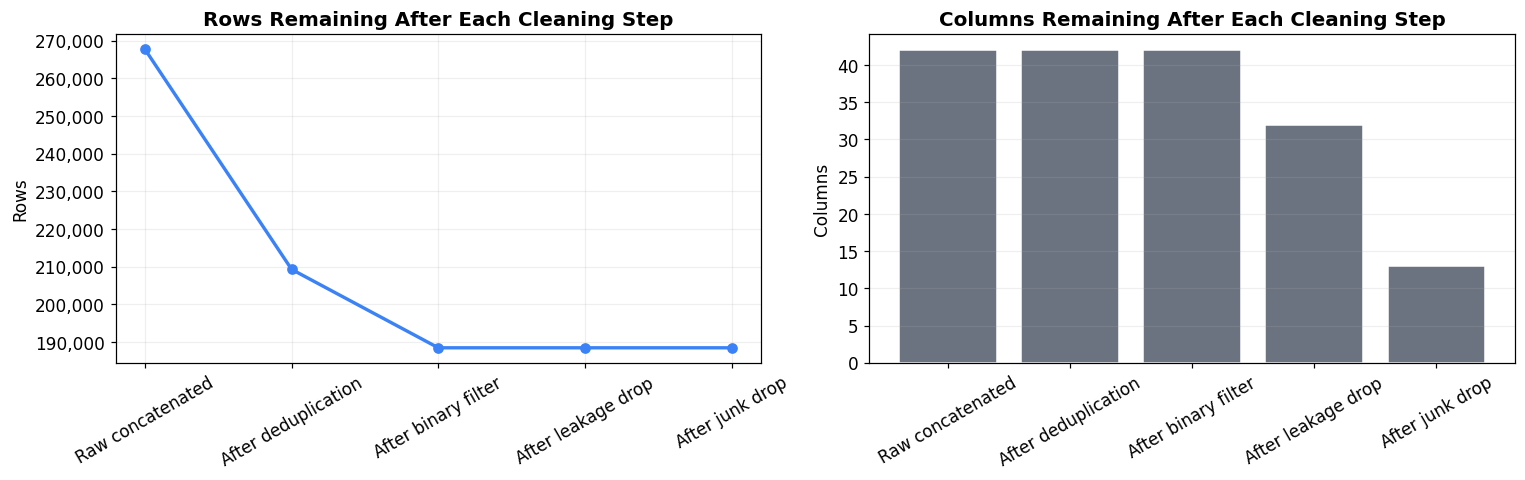

Row retention: 70.4% of raw data carried through to clean output


In [10]:
if audit is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Left: rows remaining
    axes[0].plot(audit["step"], audit["rows"], marker="o", lw=2.2, color=SUCCESS_COLOR)
    axes[0].set_title("Rows Remaining After Each Cleaning Step", fontweight="bold")
    axes[0].set_ylabel("Rows")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    axes[0].grid(alpha=0.2)

    # Right: columns remaining
    axes[1].bar(audit["step"], audit["cols"], color=NEUTRAL_COLOR, edgecolor="white")
    axes[1].set_title("Columns Remaining After Each Cleaning Step", fontweight="bold")
    axes[1].set_ylabel("Columns")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].grid(axis="y", alpha=0.2)

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_PATH, "00_drop_audit.png"), dpi=150, bbox_inches="tight")
    plt.show()

    final_retention = 100 * audit.iloc[-1]["rows"] / audit.iloc[0]["rows"]
    print(f"Row retention: {final_retention:.1f}% of raw data carried through to clean output")

### Drop audit interpretation

The data reduction is **not arbitrary** — each step improves the validity of the supervised learning problem:

- **Deduplication** avoids double-counting the same campaign in training. Campaigns appearing more than once would bias the model towards their characteristics.
- **Binary filter** makes the target well-defined. Non-binary states (`live`, `canceled`, etc.) have no interpretable ground truth for a classification task.
- **Leakage removal** protects against inflated model performance. Columns like `pledged` and `spotlight` would give the model access to post-campaign information it could never have at prediction time.
- **Junk removal** keeps the pipeline simpler and more reproducible. URL blobs and constant columns add complexity without any predictive value.

## Step 9 — Missing Value Audit and Fixes

Missingness is not only a technical issue — it often carries **domain meaning**. Rather than applying one blanket rule, we separate variables into three cases:

- **Missing means absence** → e.g. no video attached. The absence itself is signal and should be preserved as a feature.
- **Missing is rare noise** → safe to impute with a simple default (empty string, `"Unknown"`).
- **Missing is structural** → e.g. `loc_state` is missing for most non-US campaigns, which changes how we should model geography.

In [12]:
# ── Audit ────────────────────────────────────────────────────────────────
missing_audit = (
    pd.DataFrame({
        "dtype"      : df.dtypes.astype(str),
        "n_missing"  : df.isna().sum(),
        "pct_missing": (100 * df.isna().mean()).round(2),
        "n_unique"   : df.nunique(dropna=True),
    })
    .sort_values("pct_missing", ascending=False)
)
display(missing_audit[missing_audit["n_missing"] > 0])

# ── Fixes ────────────────────────────────────────────────────────────────
df["blurb"]           = df["blurb"].fillna("")                  # treat as no description
df["cat_parent_name"] = df["cat_parent_name"].fillna("Unknown") # JSON parse failure; rare
df["loc_state"]       = df["loc_state"].fillna("Unknown")       # non-US campaigns have no state
df["loc_country"]     = df["loc_country"].fillna(df["country"]) # backfill from ISO column
# video left as-is — absence is informative; has_video flag built in Notebook 03

remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
print(f"Missing after fixes:{remaining}")

,dtype,n_missing,pct_missing,n_unique
video,object,62016,32.9100,126413
cat_parent_name,object,4210,2.2300,15
loc_state,object,195,0.1000,1196
loc_country,object,146,0.0800,207
blurb,object,4,0.0000,185968


Missing after fixes:video    62016
dtype: int64


### Imputation plan summary

| Column | Strategy | Rationale |
|---|---|---|
| `blurb` | Fill `""` | Missing = creator left description blank; zero-length string lets text-length features work cleanly |
| `cat_parent_name` | Fill `"Unknown"` | JSON parse failure on a small fraction; keeps the row and makes the missingness a visible category |
| `loc_state` | Fill `"Unknown"` | Structural for non-US campaigns — forcing a state would be incorrect |
| `loc_country` | Backfill from `country` | Both encode the same information; `country` is always present |
| `video` | **Deferred** | Absence = no video attached — this is a meaningful feature, not random noise; a `has_video` binary flag is built in Notebook 03 |

## Step 10 — Final Column Inventory

Before saving, we verify the final column set and confirm that all expected extracted columns are present.

In [13]:
inventory = pd.DataFrame({
    "column"     : df.columns,
    "dtype"      : df.dtypes.values,
    "n_unique"   : [df[c].nunique() for c in df.columns],
    "pct_missing": [(df[c].isna().mean() * 100).round(2) for c in df.columns],
})
print(f"Final shape: {df.shape}")
inventory

Final shape: (188429, 18)


,column,dtype,n_unique,pct_missing
0,blurb,object,185969,0.0000
1,country,object,25,0.0000
2,created_at,int64,188371,0.0000
3,currency,object,15,0.0000
4,deadline,int64,178841,0.0000
5,disable_communication,bool,2,0.0000
6,goal,float64,6268,0.0000
7,id,int64,188429,0.0000
8,launched_at,int64,188210,0.0000
9,name,object,187869,0.0000


## Step 11 — Save Output

We save one clean parquet file. Parquet preserves column dtypes, compresses better than CSV, and is 3–5× faster to read.

The train/validation/test split and all post-cleaning analysis are handled in **Notebook 02 (EDA)**.

In [14]:
clean_path = os.path.join(OUTPUTS_PATH, "clean_df.parquet")
df.to_parquet(clean_path, index=False)

print(f"Saved clean_df : {len(df):,} rows × {df.shape[1]} cols")
print(f"Output path    : {os.path.abspath(clean_path)}")
print("\nNotebook 01 complete. Proceed to 02_EDA.ipynb")

Saved clean_df : 188,429 rows × 18 cols
Output path    : /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/notebooks_final/data/clean_df.parquet

Notebook 01 complete. Proceed to 02_EDA.ipynb
